In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import re
big_plt_font()

In [2]:
data_dir = '/home/electron/data/experiment_07142026'
all_files = list_filenames(data_dir)

In [3]:
file = load_latest_data() 
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 
data_avg = np.mean(data, axis=0) 
plot(t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')

KeyError: 'all_meas'

In [4]:
file['filename']

'/home/electron/data/experiment_07142026/RFPowerConstSweepTipSwitched_10-15-04.h5'

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Your existing data setup remains here ---
# (Ensure t_axis and data are defined above this cell)
file = load_latest_data() #load_h5_data('/home/electron/data/experiment_07082026/RFPowerSweepOnOff_15-13-34.h5') #
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 

# 1. Setup UI elements (Slider and Navigation Buttons)
slider = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(data) - 1, 
    step=1, 
    description='Index (i):'
)

btn_prev = widgets.Button(
    description='Prev',
    button_style='info',     # Light blue styling
    icon='arrow-left'        # Left arrow icon
)

btn_next = widgets.Button(
    description='Next',
    button_style='primary',  # Darker blue styling
    icon='arrow-right'       # Right arrow icon
)

# Output container to catch the plot and refresh it cleanly
plot_output = widgets.Output()

# 2. Plotting logic wrapped in an output handler
def draw_plot(i):
    with plot_output:
        clear_output(wait=True)  # Instantly clears the old plot
        
        fig, ax = plt.subplots(figsize=(7, 4))
        # Using your exact variables and scalings
        ax.plot(t_axis * 1e3, data[i], color='blue', lw=2)
        
        ax.set_title(f"Plotting dataset i = {i}")
        ax.set_xlabel("Wait time (ms)")
        ax.set_ylabel("Power (dBm)")
        ax.grid(True)
        plt.show()

# 3. Define event behaviors
def on_slider_change(change):
    draw_plot(change['new'])

def on_next_clicked(b):
    # Advances the slider, looping back to 0 if at the end
    if slider.value < slider.max:
        slider.value += 1
    else:
        slider.value = 0

def on_prev_clicked(b):
    # Rewinds the slider, looping to the end if at 0
    if slider.value > slider.min:
        slider.value -= 1
    else:
        slider.value = slider.max

# Link actions to the widgets
slider.observe(on_slider_change, names='value')
btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# 4. Pack layouts in a clean media-player style order and display
controls = widgets.HBox([btn_prev, slider, btn_next])
ui = widgets.VBox([controls, plot_output])

display(ui)

# Render the very first plot upon cell execution
draw_plot(slider.value)

KeyError: 'all_meas'

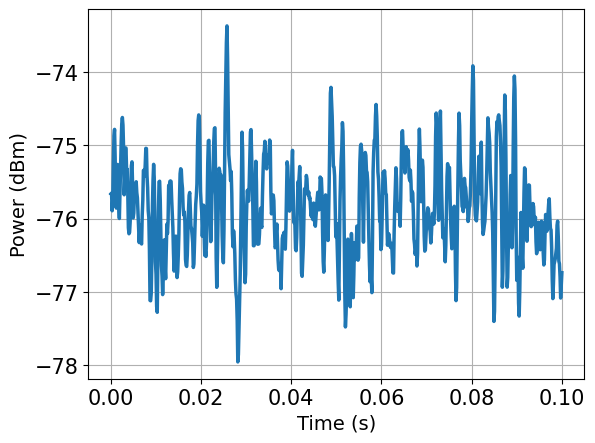

In [18]:
file2 = load_h5_data('data/experiment_07082026/RFPowerSweepOnOff_11-00-56.h5', base='/home/electron/') 
data2 = file2['all_meas'] 
t_seq_end2 = file2['t_data']
t_axis2 = np.linspace(0, t_seq_end2, len(data2[0])) 
data_avg2 = np.mean(data2, axis=0) 
plot(t_axis2, data_avg2, xlabel='Time (s)', ylabel='Power (dBm)')

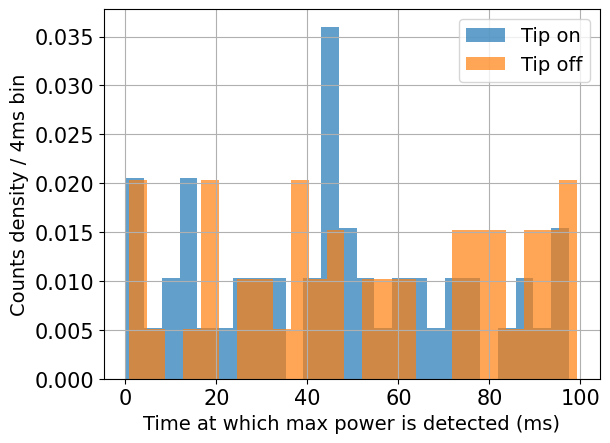

In [14]:
peak_time = []
for i in range(len(data)): 
    peak_time.append(t_axis[np.argmax(data[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip on', alpha=0.7, density=True)
peak_time = []
for i in range(len(data2)): 
    peak_time.append(t_axis2[np.argmax(data2[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip off', alpha=0.7, density=True)
plt.xlabel('Time at which max power is detected (ms)') 
plt.ylabel('Counts density / 4ms bin') 
plt.legend()
plt.grid() 
plt.show()

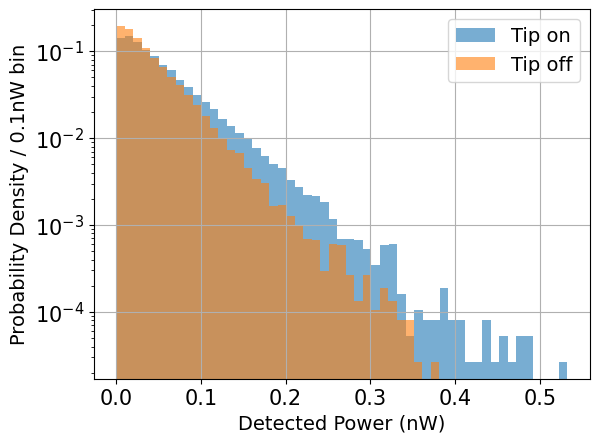

In [121]:
file = load_latest_data()#load_h5_data('/home/electron/data/experiment_07092026/RFPowerSweepOnOffDifferential_13-44-13.h5') #
data = file['all_meas'] 
file2 = load_h5_data('/home/electron/data/experiment_07092026/RFPowerSweepOnOffDifferential_12-26-39.h5') 
data2 = file2['all_meas'] 
P_nW = dBm_to_W(np.concatenate(data, axis=0))*1e9 
P_nW_background = dBm_to_W(np.concatenate(data2, axis=0))*1e9
bin_size = 0.01

counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW)-min(P_nW))/bin_size))#, alpha=0.7, label='Tip on')
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip on',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)

counts, bin_edges = np.histogram(P_nW_background, bins=int((max(P_nW_background)-min(P_nW_background))/bin_size))#, alpha=0.7, label='Tip off')
# plt.xscale('log') 
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip off',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)



plt.yscale('log')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.1nW bin')
plt.grid()
plt.legend()
plt.show()

In [7]:
def value_extraction(key): 
    pattern = r"dBm(?P<dBm_val>[-+]?\d*\.\d+|\d+)_average(?P<average>\d+)_repetition(?P<repetition>\d+)_data"
    match = re.match(pattern, key)
    data = match.groupdict()
    
    # Convert extracted strings to their proper numerical types
    dBm_Valon = float(data['dBm_val'])
    average = int(data['average'])
    repetition = int(data['repetition'])
    return dBm_Valon, average, repetition

def convert_dict_to_dataframe(input_dict):
    # Regex pattern to capture the values and determine if it's data or time
    pattern = r"dBm(?P<dBm>[-+]?\d*\.\d+|\d+)_average(?P<avg>\d+)_repetition(?P<rep>\d+)_(?P<type>data|time)"
    
    # Dictionary to temporarily store grouped records
    grouped_records = {}
    
    for key, val_array in input_dict.items():
        match = re.match(pattern, key)
        if match:
            # print('here')
            metadata = match.groupdict()
            # Convert extracted strings to their proper types
            dBm_val = float(metadata['dBm'])
            avg_val = int(metadata['avg'])
            rep_val = int(metadata['rep'])
            data_type = metadata['type']  # This will be either 'data' or 'time'
            
            # Unique identifier for this specific combination
            combo_key = (dBm_val, avg_val, rep_val)
            
            # Initialize the row structure if we haven't seen this combination yet
            if combo_key not in grouped_records:
                grouped_records[combo_key] = {
                    'dBm': dBm_val,
                    'avg': avg_val,
                    'rep': rep_val,
                    'data': None,
                    'time': None
                }
            
            # Assign the numpy array to the correct column ('data' or 'time')
            grouped_records[combo_key][data_type] = val_array

    # Convert the dictionary values into a list of rows and create the DataFrame
    df = pd.DataFrame(list(grouped_records.values()))
    
    # Optional: Reorder columns explicitly to match your request
    # df = df[['dBm', 'avg', 'rep', 'data', 'time']]
    
    return df

In [108]:
data_dict = load_h5_data('data/experiment_07092026/RFPowerConstSweepTipSwitched_16-17-44.h5', base='/home/electron')
print(f"Ex {data_dict['Ex']}, U2 {data_dict['U2']}")
df = convert_dict_to_dataframe(data_dict)

Ex 0, U2 -0.4


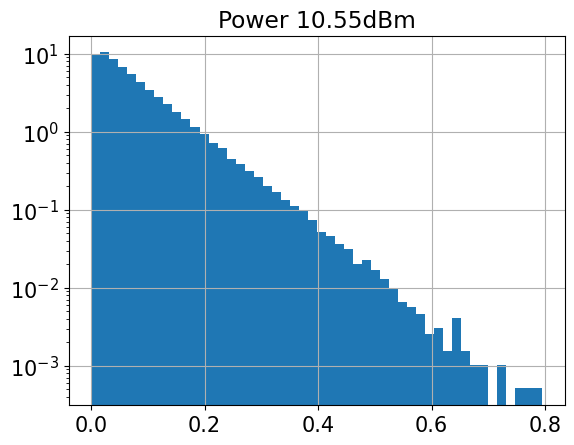

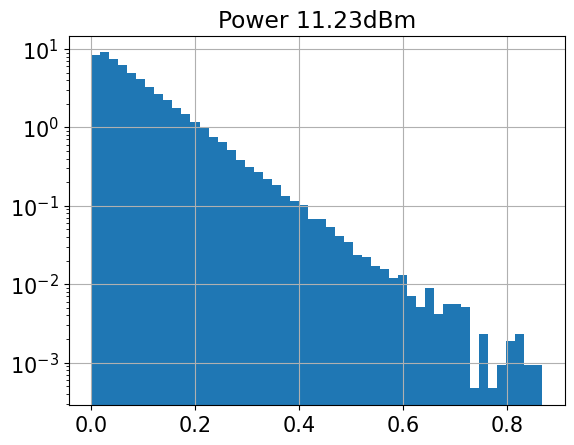

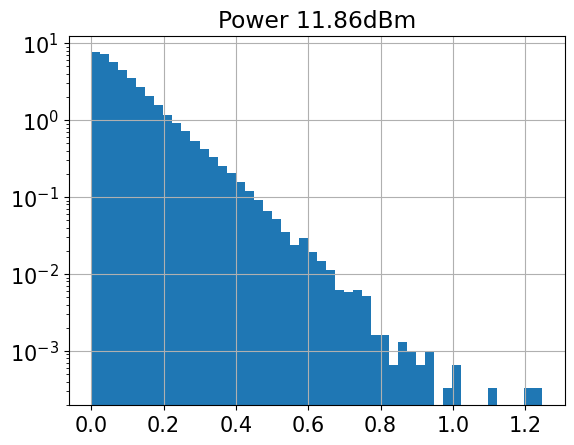

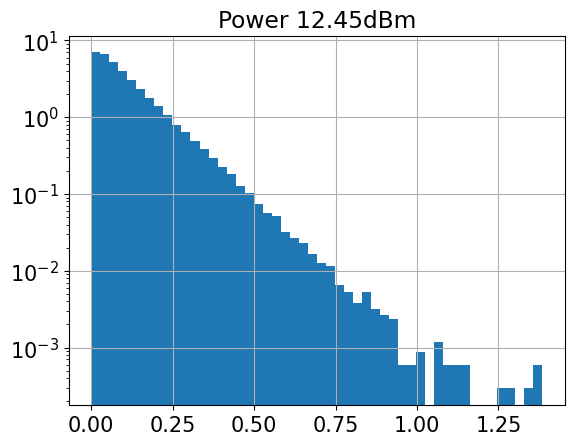

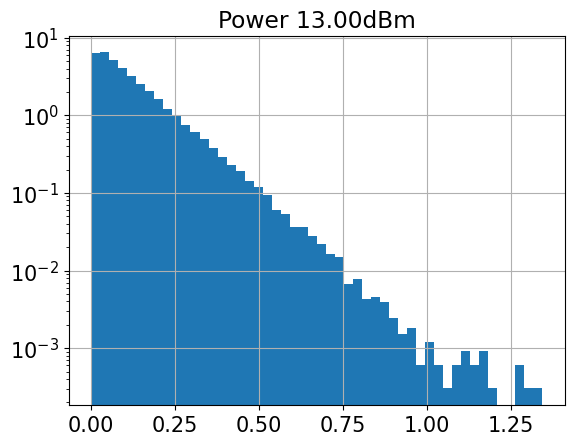

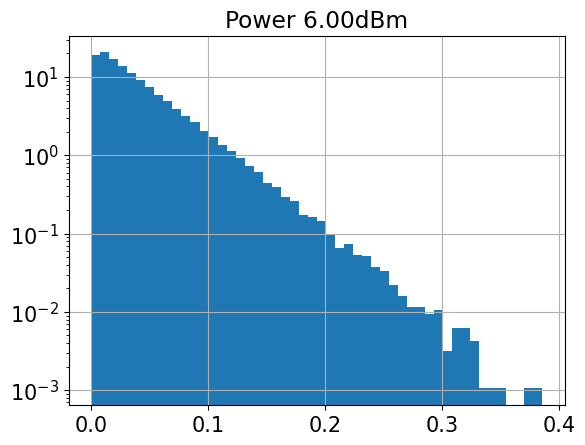

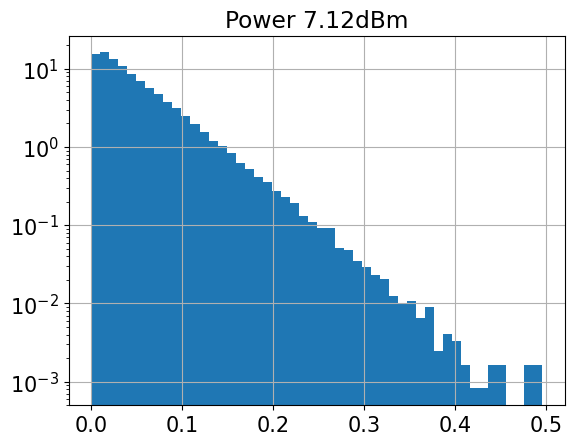

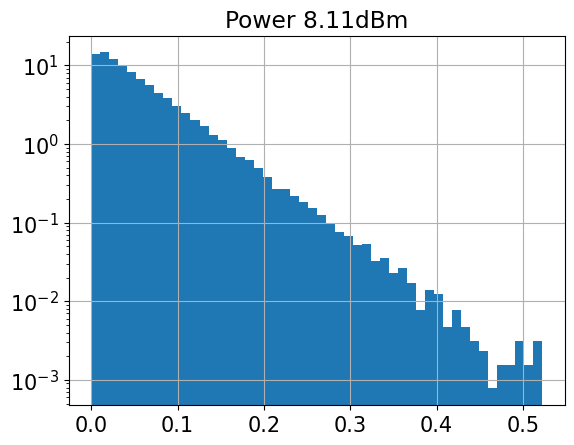

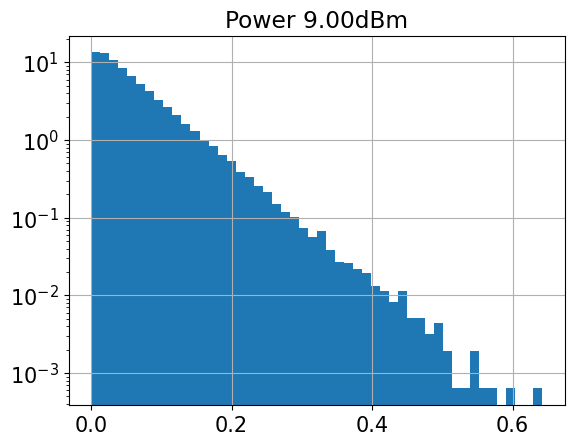

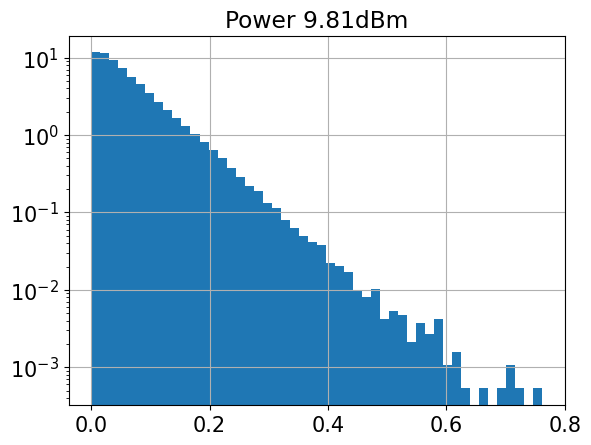

In [109]:
all_dBm = df['dBm']
all_data = [] 
for P in range(len(all_dBm)): 
    data = dBm_to_W(np.array(df['data'][P]))*1e9
    max_data = len(data[np.where(data > 10*np.mean(data))])/len(data) #- np.mean(data[:np.argmax(data)-1])
    all_data.append(max_data)
    plt.hist(data, density=True, bins=50)
    plt.title(f'Power {all_dBm[P]:.2f}dBm')
    plt.yscale('log')
    plt.grid() 
    plt.show()
    # print(np.array(df['data'][P])) 
    # break

In [ ]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_10-15-04.h5']
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base=data_dir)
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")

# 3. Define the plotting function that the widget will trigger
# 3. Define the plotting function that the widget will trigger
def plot_experiment_data(Ex, U2, Power_dBm):
    # Guard against initialization / update frames where values are momentarily None
    if Ex is None or U2 is None or Power_dBm is None:
        return
        
    filepath = experiment_map.get((Ex, U2))
    
    if not filepath:
        print(f"No file found for Ex: {Ex}, U2: {U2}")
        return
        
    # Load and process the specific file
    data_dict = load_h5_data(filepath, base=data_dir)
    df = convert_dict_to_dataframe(data_dict)
    
    # Find the row corresponding to the selected power
    # Converting df['dBm'] to a float series explicitly just in case it's loaded as object type
    dbm_series = df['dBm'].astype(float)
    row = df[np.isclose(dbm_series, float(Power_dBm), atol=1e-3)]
    
    if row.empty:
        print(f"Power {Power_dBm} dBm not found in this dataset.")
        return
        
    # Extract the data array for this specific power level
    raw_data = row['data'].values[0]
    data = dBm_to_W(np.array(raw_data)) * 1e9
    
    # Calculate your metric (fraction of data > 10x mean)
    mean_val = np.mean(data)
    if mean_val > 0:
        max_data = len(data[data > 10 * mean_val]) / len(data)
    else:
        max_data = 0
        
    # Generate the plot
    plt.figure(figsize=(8, 5))
    plt.hist(data, density=True, bins=50, alpha=0.75, color='b', edgecolor='black')
    plt.title(f'Ex: {Ex} | U2: {U2} | Power: {Power_dBm:.2f} dBm\nMetric ( >10x Mean Ratio): {max_data:.4f}')
    # plt.xlim(-0.1,)
    plt.xlabel('Power (nW)')
    plt.ylabel('Density (Log Scale)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')

def update_power_options(*args):
    filepath = experiment_map.get((ex_dropdown.value, u2_dropdown.value))
    if filepath:
        # Quickly load dataframe to extract available power levels for this specific file
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        power_dropdown.options = sorted(df['dBm'].unique())
    else:
        power_dropdown.options = []

# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 1 valid Ex/U2 configurations.


In [ ]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
h5_files = ['RFPowerConstSweepTipSwitched_10-26-26.h5']

# 2. Pre-scan files to map (Ex, U2) -> File Path AND find global max power
experiment_map = {}
global_max_power_nw = 0.0  # Track global maximum across ALL data

print("Scanning datasets...")
for filepath in h5_files:
    try:
        data_dict = load_h5_data(filepath, base=data_dir)
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            experiment_map[(ex_val, u2_val)] = filepath
            
            # --- CALCULATE GLOBAL MAX POWER ---
            df = convert_dict_to_dataframe(data_dict)
            # Flatten all raw data nested arrays for this file, convert to nW, and check max
            for raw_data in df['data'].values:
                data_nw = dBm_to_W(np.array(raw_data)) * 1e9
                if len(data_nw) > 0:
                    global_max_power_nw = max(global_max_power_nw, np.max(data_nw))
                    
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

# Set a safety padding for xmax (e.g., 5% past the absolute max)
global_xmax = global_max_power_nw * 1.05 

print(f"Scan complete. Found {len(experiment_map)} configurations.")
print(f"Global Maximum Power Found: {global_max_power_nw:.2f} nW (Axis limit set to: {global_xmax:.2f} nW)")

# 3. Define the plotting function with fixed xlim and ylim
def plot_experiment_data(Ex, U2, Power_dBm):
    if Ex is None or U2 is None or Power_dBm is None:
        return
        
    filepath = experiment_map.get((Ex, U2))
    if not filepath:
        print(f"No file found for Ex: {Ex}, U2: {U2}")
        return
        
    data_dict = load_h5_data(filepath, base=data_dir)
    df = convert_dict_to_dataframe(data_dict)
    
    dbm_series = df['dBm'].astype(float)
    row = df[np.isclose(dbm_series, float(Power_dBm), atol=1e-3)]
    
    if row.empty:
        print(f"Power {Power_dBm} dBm not found in this dataset.")
        return
        
    raw_data = row['data'].values[0]
    data = dBm_to_W(np.array(raw_data)) * 1e9
    
    mean_val = np.mean(data)
    max_data = len(data[data > 10 * mean_val]) / len(data) if mean_val > 0 else 0
        
    # Generate the plot
    plt.figure(figsize=(8, 5))
    plt.hist(data, density=True, bins=50, alpha=0.75, color='b', edgecolor='black')
    plt.title(f'Ex: {Ex} | U2: {U2} | Power: {Power_dBm:.2f} dBm\nMetric ( >10x Mean Ratio): {max_data:.4f}')
    
    # --- FIXED AXIS LIMITS ---
    plt.xlim(-0.1, global_xmax) 
    plt.ylim(1e-6, 100.0) # Set fixed log limits (adjust 1e-6 and 10.0 to fit your data range)
    
    plt.xlabel('Power (nW)')
    plt.ylabel('Density (Log Scale)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

# 4. Create Dynamic Interactive Dashboard
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')

def update_power_options(*args):
    filepath = experiment_map.get((ex_dropdown.value, u2_dropdown.value))
    if filepath:
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        power_dropdown.options = sorted(df['dBm'].unique())
    else:
        power_dropdown.options = []

ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

update_power_options()

interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 1 configurations.
Global Maximum Power Found: 2.98 nW (Axis limit set to: 3.13 nW)


In [ ]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
h5_files = ['RFPowerConstSweepTipSwitched_10-26-26.h5']

# 2. Pre-scan files to map (Ex, U2) -> File Path AND find global max power
experiment_map = {}
global_max_power_dBm = -100  # Track global maximum across ALL data
global_min_power_dBm = 0.0

print("Scanning datasets...")
for filepath in h5_files:
    try:
        data_dict = load_h5_data(filepath, base=data_dir)
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            experiment_map[(ex_val, u2_val)] = filepath
            
            # --- CALCULATE GLOBAL MAX POWER ---
            df = convert_dict_to_dataframe(data_dict)
            # Flatten all raw data nested arrays for this file, convert to nW, and check max
            for raw_data in df['data'].values:
                # data_nw = dBm_to_W(np.array(raw_data)) * 1e9
                data_dBm = np.array(raw_data)
                if len(data_dBm) > 0:
                    global_max_power_dBm = max(global_max_power_dBm, np.max(data_dBm))
                    global_min_power_dBm = min(global_min_power_dBm,np.min(data_dBm))
                    
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

# Set a safety padding for xmax (e.g., 5% past the absolute max)
global_xmax = global_max_power_dBm * 1.05 
global_xmin = global_min_power_dBm *1.05

print(f"Scan complete. Found {len(experiment_map)} configurations.")
print(f"Global Maximum Power Found: {global_max_power_dBm:.2f} dBm (Axis limit set to: {global_xmax:.2f} dBm)")

# 3. Define the plotting function with fixed xlim and ylim
def plot_experiment_data(Ex, U2, Power_dBm):
    if Ex is None or U2 is None or Power_dBm is None:
        return
        
    filepath = experiment_map.get((Ex, U2))
    if not filepath:
        print(f"No file found for Ex: {Ex}, U2: {U2}")
        return
        
    data_dict = load_h5_data(filepath, base=data_dir)
    df = convert_dict_to_dataframe(data_dict)
    
    dbm_series = df['dBm'].astype(float)
    row = df[np.isclose(dbm_series, float(Power_dBm), atol=1e-3)]
    
    if row.empty:
        print(f"Power {Power_dBm} dBm not found in this dataset.")
        return
        
    raw_data = row['data'].values[0]
    # data = dBm_to_W(np.array(raw_data)) * 1e9
    data = np.array(raw_data)
    
    mean_val = np.mean(data)
    max_data = len(data[data > 10 * mean_val]) / len(data) if mean_val > 0 else 0
        
    # Generate the plot
    plt.figure(figsize=(8, 5))
    plt.hist(data, density=True, bins=50, alpha=0.75, color='b', edgecolor='black')
    plt.title(f'Ex: {Ex} | U2: {U2} | Power: {Power_dBm:.2f} dBm\nMetric ( >10x Mean Ratio): {max_data:.4f}')
    
    # --- FIXED AXIS LIMITS ---
    plt.xlim(global_xmin, global_xmax) 
    plt.ylim(1e-6, 100.0) # Set fixed log limits (adjust 1e-6 and 10.0 to fit your data range)
    
    plt.xlabel('Power (dBm)')
    plt.ylabel('Density (Log Scale)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

# 4. Create Dynamic Interactive Dashboard
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')

def update_power_options(*args):
    filepath = experiment_map.get((ex_dropdown.value, u2_dropdown.value))
    if filepath:
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        power_dropdown.options = sorted(df['dBm'].unique())
    else:
        power_dropdown.options = []

ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

update_power_options()

interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 1 configurations.
Global Maximum Power Found: -60.57 dBm (Axis limit set to: -63.60 dBm)


In [147]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_18-46-18.h5',
 'RFPowerConstSweepTipSwitched_18-47-33.h5',
              'RFPowerConstSweepTipSwitched_18-48-47.h5','RFPowerConstSweepTipSwitched_18-50-02.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [145]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_18-52-14.h5',
 'RFPowerConstSweepTipSwitched_18-53-29.h5',
              'RFPowerConstSweepTipSwitched_18-54-43.h5','RFPowerConstSweepTipSwitched_18-55-57.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [144]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_19-00-15.h5', 
            'RFPowerConstSweepTipSwitched_19-01-29.h5','RFPowerConstSweepTipSwitched_19-02-43.h5','RFPowerConstSweepTipSwitched_19-03-58.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [148]:
from scipy.constants import m_e, e
176.2190 - np.sqrt(0.4*e/np.sqrt(20/16/np.pi)/(m_e/2)*1e6)/2/np.pi/1e6

np.float64(101.0505164590578)

In [152]:
np.sqrt(1*e*np.sqrt(20/16/np.pi)/(m_e/2)*1e6)/2/np.pi/1e6

np.float64(74.9697155953526)